# ML Predictor Comparison: Baseline vs Probability Filter

This notebook compares the original predictor in `ML_predictor.py` with the probability-aware predictor in `ML_predictor_probability.py`.

Both strategies use the same data, walk-forward training window, feature grid, signal thresholds, backtester, and execution settings. The probability strategy uses its default `probability_threshold=0.60`, so it assigns a non-zero weight only when its most likely class has probability strictly above 60%.

The structure follows `test_PCA_scaler_comparison.ipynb`: parallel grid execution, saved case artifacts, performance leaderboards, matched-grid deltas, heatmaps, prediction agreement, diagnostics, and winner equity curves.

## 1. Setup

In [1]:
from pathlib import Path
import sys
import time
import json
import itertools
import warnings

from joblib import Parallel, delayed
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

cwd = Path.cwd().resolve()
repo_root = cwd
while repo_root.name != "Bluegrey" and repo_root.parent != repo_root:
    repo_root = repo_root.parent

ml_dir = repo_root / "research" / "Mateo" / "ML_predictor"
src_dir = repo_root / "src"
for path in [repo_root, src_dir, ml_dir]:
    path_str = str(path)
    if path_str not in sys.path:
        sys.path.insert(0, path_str)

from ML_predictor import MLPredictorStrategy as BaselineStrategy
from ML_predictor_probability import MLPredictorStrategy as ProbabilityStrategy
from src.vector_backtester_Mateo import PortfolioVectorEngine

print(f"Repo root: {repo_root}")
print(f"ML directory: {ml_dir}")

Repo root: /Users/mateo/Bluegrey
ML directory: /Users/mateo/Bluegrey/research/Mateo/ML_predictor


## 2. Grid Specification

The requested grid contains 72 runs: two strategies × nine `n_features` values × four `signal_threshold` values. `training_years` is fixed at 10.

In [2]:
SYMBOL = "ECH"
ASSET_CLASS = "STK"
INITIAL_CAPITAL = 1_000_000
EXECUTION_DELAY = 1

STRATEGIES = {
    "baseline": BaselineStrategy,
    "probability_60pct": ProbabilityStrategy,
}
TRAINING_YEARS = 10
N_FEATURES_GRID = list(range(3, 20, 2))
SIGNAL_THRESHOLD_GRID = [0.000, 0.001, 0.002, 0.003]
PROBABILITY_THRESHOLD = 0.60

COMMON_PARAMS = {
    "symbol": SYMBOL,
    "start_date": "2025-01-01",
    "end_date": "2026-01-01",
    "training_years": TRAINING_YEARS,
    "download_data": False,
    "position_size": 1.0,
    "max_iter": 5000,
    "verbose": False,
}

RUN_GRID = True
N_JOBS = 12
PARALLEL_VERBOSE = 10
SHOW_PROGRESS = False
SAVE_ARTIFACTS = True

OUTPUT_DIR = ml_dir / "test_probability_strategy_comparison_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

grid_cases = list(itertools.product(STRATEGIES, N_FEATURES_GRID, SIGNAL_THRESHOLD_GRID))
assert N_FEATURES_GRID == [3, 5, 7, 9, 11, 13, 15, 17, 19]
assert SIGNAL_THRESHOLD_GRID == [0.000, 0.001, 0.002, 0.003]
assert len(grid_cases) == 72

print(f"Grid cases: {len(grid_cases)} ({len(grid_cases) // len(STRATEGIES)} matched points per strategy)")
print(f"Output directory: {OUTPUT_DIR}")

Grid cases: 72 (36 matched points per strategy)
Output directory: /Users/mateo/Bluegrey/research/Mateo/ML_predictor/test_probability_strategy_comparison_outputs


## 3. Helper Functions

These helpers follow the PCA comparison notebook's conventions for run IDs, performance statistics, artifact persistence, and self-contained single-case execution.

In [3]:
def safe_value(value):
    if isinstance(value, (float, np.floating)):
        value = float(value)
        if value.is_integer():
            return str(int(value))
        return f"{value:g}".replace(".", "p")
    return str(value)


def make_run_id(symbol: str, strategy_name: str, n_features: int, signal_threshold: float) -> str:
    return (
        f"{symbol}_strategy-{strategy_name}"
        f"_features-{n_features}"
        f"_sig-{safe_value(signal_threshold)}"
    )


def annualized_sharpe(returns: pd.Series, periods_per_year: int = 252) -> float:
    returns = returns.dropna()
    volatility = returns.std()
    if volatility == 0 or np.isnan(volatility):
        return np.nan
    return np.sqrt(periods_per_year) * returns.mean() / volatility


def annualized_sortino(returns: pd.Series, periods_per_year: int = 252) -> float:
    returns = returns.dropna()
    downside_volatility = returns[returns < 0].std()
    if downside_volatility == 0 or np.isnan(downside_volatility):
        return np.nan
    return np.sqrt(periods_per_year) * returns.mean() / downside_volatility


def max_drawdown(equity: pd.Series) -> float:
    return (equity / equity.cummax() - 1.0).min()


def summarize_performance(
    run_id: str,
    strategy_name: str,
    params: dict,
    stats: pd.DataFrame,
    weights: pd.DataFrame,
    predictions: pd.DataFrame,
    elapsed_seconds: float,
) -> dict:
    gross_return_pct = (stats["gross_equity"].iloc[-1] / INITIAL_CAPITAL - 1.0) * 100
    net_return_pct = (stats["net_equity"].iloc[-1] / INITIAL_CAPITAL - 1.0) * 100
    benchmark_return_pct = (stats["cum_benchmark"].iloc[-1] - 1.0) * 100
    gross_bar_returns = stats["gross_returns"].iloc[1:]
    exposure = weights.abs().sum(axis=1)
    turnover = weights.diff().abs().sum(axis=1).fillna(0)
    prediction_counts = predictions["prediction"].value_counts(normalize=True).sort_index() * 100
    max_probability = predictions.get("max_probability", pd.Series(np.nan, index=predictions.index))
    passed_filter = predictions.get("passes_probability_threshold", pd.Series(True, index=predictions.index))

    return {
        "run_id": run_id,
        "strategy": strategy_name,
        "symbol": params["symbol"],
        "n_features": params["n_features"],
        "signal_threshold": params["signal_threshold"],
        "training_years": params["training_years"],
        "probability_threshold": params.get("probability_threshold", np.nan),
        "gross_return_pct": gross_return_pct,
        "net_return_pct": net_return_pct,
        "benchmark_return_pct": benchmark_return_pct,
        "excess_vs_benchmark_pct": net_return_pct - benchmark_return_pct,
        "max_drawdown_pct": max_drawdown(stats["net_equity"]) * 100,
        "net_sharpe": annualized_sharpe(stats["net_returns"]),
        "net_sortino": annualized_sortino(stats["net_returns"]),
        "win_rate_pct": (gross_bar_returns > 0).mean() * 100,
        "loss_rate_pct": (gross_bar_returns < 0).mean() * 100,
        "zero_rate_pct": (gross_bar_returns == 0).mean() * 100,
        "active_days_pct": (exposure > 0).mean() * 100,
        "long_days_pct": (weights.sum(axis=1) > 0).mean() * 100,
        "short_days_pct": (weights.sum(axis=1) < 0).mean() * 100,
        "flat_days_pct": (weights.sum(axis=1) == 0).mean() * 100,
        "average_abs_exposure": exposure.mean(),
        "average_daily_turnover": turnover.mean(),
        "total_fees_paid": stats["cumulative_costs"].iloc[-1],
        "prediction_minus1_pct": prediction_counts.get(-1.0, 0.0),
        "prediction_0_pct": prediction_counts.get(0.0, 0.0),
        "prediction_plus1_pct": prediction_counts.get(1.0, 0.0),
        "mean_max_probability": max_probability.mean(),
        "median_max_probability": max_probability.median(),
        "passes_probability_threshold_pct": passed_filter.mean() * 100,
        "elapsed_seconds": elapsed_seconds,
    }

In [4]:
def save_case_artifacts(run_id: str, artifacts: dict) -> None:
    run_dir = OUTPUT_DIR / run_id
    run_dir.mkdir(parents=True, exist_ok=True)
    artifacts["stats"].to_pickle(run_dir / "portfolio_stats.pkl")
    artifacts["weights"].to_pickle(run_dir / "weights.pkl")
    artifacts["predictions"].to_pickle(run_dir / "predictions.pkl")
    with open(run_dir / "metrics.json", "w") as file:
        json.dump(artifacts["metrics"], file, indent=2, default=str)


def run_one_case(strategy_name: str, n_features: int, signal_threshold: float) -> dict:
    run_id = make_run_id(SYMBOL, strategy_name, n_features, signal_threshold)
    print(f"Running {run_id}")
    start = time.time()

    params = {
        **COMMON_PARAMS,
        "n_features": n_features,
        "signal_threshold": signal_threshold,
    }
    if strategy_name == "probability_60pct":
        params["probability_threshold"] = PROBABILITY_THRESHOLD

    strategy = STRATEGIES[strategy_name](params=params)
    dataset = strategy.prepare_dataset()
    prediction_output = strategy.predict(dataset, show_progress=SHOW_PROGRESS)

    if isinstance(prediction_output, pd.Series):
        predictions = prediction_output.rename("prediction").to_frame()
        weights = predictions[["prediction"]].rename(columns={"prediction": SYMBOL})
        weights[SYMBOL] *= params["position_size"]
        predictions["max_probability"] = np.nan
        predictions["passes_probability_threshold"] = True
    else:
        predictions = prediction_output.copy()
        probability_columns = ["probability_-1", "probability_0", "probability_1"]
        predictions["max_probability"] = predictions[probability_columns].max(axis=1)
        predictions["passes_probability_threshold"] = predictions["max_probability"] > params["probability_threshold"]
        weights = predictions[["prediction"]].rename(columns={"prediction": SYMBOL})
        weights[SYMBOL] = weights[SYMBOL].where(predictions["passes_probability_threshold"], 0)
        weights[SYMBOL] *= params["position_size"]

    prices = dataset[["Open"]].rename(columns={"Open": SYMBOL}).loc[weights.index]
    engine = PortfolioVectorEngine(
        prices=prices,
        signals=weights,
        asset_class=ASSET_CLASS,
        initial_capital=INITIAL_CAPITAL,
        execution_delay=EXECUTION_DELAY,
    )
    stats = engine.run()
    metrics = summarize_performance(
        run_id,
        strategy_name,
        params,
        stats,
        weights,
        predictions,
        time.time() - start,
    )
    artifacts = {
        "run_id": run_id,
        "params": params,
        "weights": weights,
        "predictions": predictions,
        "prices": prices,
        "stats": stats,
        "metrics": metrics,
    }
    if SAVE_ARTIFACTS:
        save_case_artifacts(run_id, artifacts)
    return artifacts

## 4. Run the Parallel Grid

This is the expensive cell. Like the PCA comparison notebook, it uses joblib's process-based `loky` backend and saves every successful run under `test_probability_strategy_comparison_outputs/`.

In [5]:
grid_artifacts = {}
grid_metrics = []
grid_errors = []


def run_one_case_safely(case):
    strategy_name, n_features, signal_threshold = case
    run_id = make_run_id(SYMBOL, strategy_name, n_features, signal_threshold)
    try:
        artifacts = run_one_case(strategy_name, n_features, signal_threshold)
        return {"ok": True, "run_id": run_id, "artifacts": artifacts}
    except Exception as exc:
        return {
            "ok": False,
            "run_id": run_id,
            "strategy": strategy_name,
            "n_features": n_features,
            "signal_threshold": signal_threshold,
            "error": repr(exc),
        }


if RUN_GRID:
    grid_results = Parallel(n_jobs=N_JOBS, backend="loky", verbose=PARALLEL_VERBOSE)(
        delayed(run_one_case_safely)(case)
        for case in grid_cases
    )

    for result in grid_results:
        if result["ok"]:
            grid_artifacts[result["run_id"]] = result["artifacts"]
            grid_metrics.append(result["artifacts"]["metrics"])
        else:
            grid_errors.append({key: value for key, value in result.items() if key != "ok"})

metrics_df = pd.DataFrame(grid_metrics)
errors_df = pd.DataFrame(grid_errors)

if SAVE_ARTIFACTS and not metrics_df.empty:
    metrics_df.to_pickle(OUTPUT_DIR / "grid_metrics.pkl")
    metrics_df.to_csv(OUTPUT_DIR / "grid_metrics.csv", index=False)
if SAVE_ARTIFACTS and not errors_df.empty:
    errors_df.to_csv(OUTPUT_DIR / "grid_errors.csv", index=False)

display(metrics_df.sort_values("net_sharpe", ascending=False).head(10))
display(errors_df)

[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.


Running ECH_strategy-baseline_features-3_sig-0p001
Running ECH_strategy-baseline_features-3_sig-0
Running ECH_strategy-baseline_features-5_sig-0
Running ECH_strategy-baseline_features-3_sig-0p002
Running ECH_strategy-baseline_features-7_sig-0p001
Running ECH_strategy-baseline_features-7_sig-0p002
Running ECH_strategy-baseline_features-7_sig-0p003
Running ECH_strategy-baseline_features-3_sig-0p003
Running ECH_strategy-baseline_features-7_sig-0
Running ECH_strategy-baseline_features-5_sig-0p002
Running ECH_strategy-baseline_features-5_sig-0p003
Running ECH_strategy-baseline_features-5_sig-0p001


/Users/mateo/miniconda3/envs/bluegrey/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
[Parallel(n_jobs=12)]: Done   1 tasks      | elapsed:  1.9min


Running ECH_strategy-baseline_features-9_sig-0


/Users/mateo/miniconda3/envs/bluegrey/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


...

[Parallel(n_jobs=12)]: Done  57 out of  72 | elapsed: 16.4min remaining:  4.3min


Running ECH_strategy-probability_60pct_features-19_sig-0p001
Running ECH_strategy-probability_60pct_features-19_sig-0p002
Running ECH_strategy-probability_60pct_features-19_sig-0p003


[Parallel(n_jobs=12)]: Done  65 out of  72 | elapsed: 19.3min remaining:  2.1min
[Parallel(n_jobs=12)]: Done  72 out of  72 | elapsed: 21.3min finished


,run_id,strategy,symbol,n_features,signal_threshold,training_years,probability_threshold,gross_return_pct,net_return_pct,benchmark_return_pct,excess_vs_benchmark_pct,max_drawdown_pct,net_sharpe,net_sortino,win_rate_pct,loss_rate_pct,zero_rate_pct,active_days_pct,long_days_pct,short_days_pct,flat_days_pct,average_abs_exposure,average_daily_turnover,total_fees_paid,prediction_minus1_pct,prediction_0_pct,prediction_plus1_pct,mean_max_probability,median_max_probability,passes_probability_threshold_pct,elapsed_seconds
27,ECH_strategy-baseline_features-15_sig-0p003,baseline,ECH,15,0.003,10,NaN,59.079112,52.807464,65.173061,-12.365597,-10.294609,1.997513,2.979905,55.020080,40.963855,4.016064,98.8,56.4,42.4,1.2,0.988,0.888,62716.483833,42.4,1.2,56.4,NaN,NaN,100.0,398.518159
70,ECH_strategy-probability_60pct_features-19_sig...,probability_60pct,ECH,19,0.002,10,0.6,4.976811,4.462226,65.173061,-60.710835,-1.181272,1.508169,1.235514,2.811245,1.606426,95.582329,4.8,1.6,3.2,95.2,0.048,0.092,5145.858379,38.4,0.0,61.6,0.498927,0.488234,4.8,192.829489
34,ECH_strategy-baseline_features-19_sig-0p002,baseline,ECH,19,0.002,10,NaN,42.544220,37.201157,65.173061,-27.971903,-10.343428,1.502055,2.224962,53.012048,44.176707,2.811245,100.0,61.6,38.4,0.0,1.000,0.848,53430.626888,38.4,0.0,61.6,NaN,NaN,100.0,262.316096
30,ECH_strategy-baseline_features-17_sig-0p002,baseline,ECH,17,0.002,10,NaN,42.355933,36.957403,65.173061,-28.215658,-11.247092,1.493273,2.093955,56.626506,40.562249,2.811245,100.0,62.8,37.2,0.0,1.000,0.864,53985.306032,37.2,0.0,62.8,NaN,NaN,100.0,341.146726
23,ECH_strategy-baseline_features-13_sig-0p003,baseline,ECH,13,0.003,10,NaN,40.861229,35.783310,65.173061,-29.389750,-22.435152,1.456182,2.231449,53.012048,44.176707,2.811245,100.0,58.4,41.6,0.0,1.000,0.864,50779.191314,41.6,0.0,58.4,NaN,NaN,100.0,343.835977
44,ECH_strategy-probability_60pct_features-7_sig-0,probability_60pct,ECH,7,0.000,10,0.6,10.589959,9.246958,65.173061,-55.926102,-3.352115,1.441944,1.090179,7.228916,4.819277,87.951807,12.0,5.6,6.4,88.0,0.120,0.216,13430.009680,37.6,0.0,62.4,0.540997,0.532939,12.0,110.876244
22,ECH_strategy-baseline_features-13_sig-0p002,baseline,ECH,13,0.002,10,NaN,38.006472,32.664857,65.173061,-32.508204,-14.292187,1.351969,1.971053,52.610442,44.578313,2.811245,100.0,64.8,35.2,0.0,1.000,0.840,53416.147423,35.2,0.0,64.8,NaN,NaN,100.0,322.404239
63,ECH_strategy-probability_60pct_features-15_sig...,probability_60pct,ECH,15,0.003,10,0.6,1.022180,0.928632,65.173061,-64.244429,-0.025147,1.328717,318.339549,0.803213,0.000000,99.196787,1.2,0.0,1.2,98.8,0.012,0.020,935.482762,42.4,1.2,56.4,0.458125,0.449755,1.2,271.998950
26,ECH_strategy-baseline_features-15_sig-0p002,baseline,ECH,15,0.002,10,NaN,35.383420,30.640198,65.173061,-34.532863,-19.014604,1.286153,1.689901,53.815261,43.373494,2.811245,100.0,67.2,32.8,0.0,1.000,0.768,47432.227895,32.8,0.0,67.2,NaN,NaN,100.0,330.698977
66,ECH_strategy-probability_60pct_features-17_sig...,probability_60pct,ECH,17,0.002,10,0.6,4.993675,4.452766,65.173061,-60.720294,-1.527271,1.179509,1.070494,2.409639,2.008032,95.582329,4.8,2.8,2.0,95.2,0.048,0.096,5409.089864,37.2,0.0,62.8,0.500738,0.490621,4.8,245.791276


""


## 5. Performance Leaderboards

Inspect net Sharpe first, then net return, drawdown, fees, activity, and turnover. The probability-specific confidence columns are `NaN` for the baseline by design.

In [6]:
leaderboard_cols = [
    "run_id", "strategy", "n_features", "signal_threshold", "probability_threshold",
    "net_return_pct", "gross_return_pct", "benchmark_return_pct", "excess_vs_benchmark_pct",
    "net_sharpe", "net_sortino", "max_drawdown_pct", "total_fees_paid",
    "win_rate_pct", "loss_rate_pct", "zero_rate_pct",
    "long_days_pct", "short_days_pct", "flat_days_pct", "average_abs_exposure",
    "prediction_minus1_pct", "prediction_0_pct", "prediction_plus1_pct",
    "active_days_pct", "average_daily_turnover", "mean_max_probability",
    "passes_probability_threshold_pct", "elapsed_seconds",
]

print("Best performers by NET SHARPE RATIO")
display(metrics_df[leaderboard_cols].sort_values("net_sharpe", ascending=False).head(15).round(3))
print("\nBest performers by NET RETURN")
display(metrics_df[leaderboard_cols].sort_values("net_return_pct", ascending=False).head(15).round(3))
print("\nBest performers by MAX DRAWDOWN")
display(metrics_df[leaderboard_cols].sort_values("max_drawdown_pct", ascending=False).head(15).round(3))

best_by_strategy = metrics_df.sort_values("net_sharpe", ascending=False).groupby("strategy").head(1)
print("\nBest net-Sharpe run from each strategy")
display(best_by_strategy[leaderboard_cols].round(3))

Best performers by NET SHARPE RATIO


,run_id,strategy,n_features,signal_threshold,probability_threshold,net_return_pct,gross_return_pct,benchmark_return_pct,excess_vs_benchmark_pct,net_sharpe,net_sortino,max_drawdown_pct,total_fees_paid,win_rate_pct,loss_rate_pct,zero_rate_pct,long_days_pct,short_days_pct,flat_days_pct,average_abs_exposure,prediction_minus1_pct,prediction_0_pct,prediction_plus1_pct,active_days_pct,average_daily_turnover,mean_max_probability,passes_probability_threshold_pct,elapsed_seconds
27,ECH_strategy-baseline_features-15_sig-0p003,baseline,15,0.003,NaN,52.807,59.079,65.173,-12.366,1.998,2.980,-10.295,62716.484,55.020,40.964,4.016,56.4,42.4,1.2,0.988,42.4,1.2,56.4,98.8,0.888,NaN,100.0,398.518
70,ECH_strategy-probability_60pct_features-19_sig...,probability_60pct,19,0.002,0.6,4.462,4.977,65.173,-60.711,1.508,1.236,-1.181,5145.858,2.811,1.606,95.582,1.6,3.2,95.2,0.048,38.4,0.0,61.6,4.8,0.092,0.499,4.8,192.829
34,ECH_strategy-baseline_features-19_sig-0p002,baseline,19,0.002,NaN,37.201,42.544,65.173,-27.972,1.502,2.225,-10.343,53430.627,53.012,44.177,2.811,61.6,38.4,0.0,1.000,38.4,0.0,61.6,100.0,0.848,NaN,100.0,262.316
30,ECH_strategy-baseline_features-17_sig-0p002,baseline,17,0.002,NaN,36.957,42.356,65.173,-28.216,1.493,2.094,-11.247,53985.306,56.627,40.562,2.811,62.8,37.2,0.0,1.000,37.2,0.0,62.8,100.0,0.864,NaN,100.0,341.147
23,ECH_strategy-baseline_features-13_sig-0p003,baseline,13,0.003,NaN,35.783,40.861,65.173,-29.390,1.456,2.231,-22.435,50779.191,53.012,44.177,2.811,58.4,41.6,0.0,1.000,41.6,0.0,58.4,100.0,0.864,NaN,100.0,343.836
44,ECH_strategy-probability_60pct_features-7_sig-0,probability_60pct,7,0.000,0.6,9.247,10.590,65.173,-55.926,1.442,1.090,-3.352,13430.010,7.229,4.819,87.952,5.6,6.4,88.0,0.120,37.6,0.0,62.4,12.0,0.216,0.541,12.0,110.876
22,ECH_strategy-baseline_features-13_sig-0p002,baseline,13,0.002,NaN,32.665,38.006,65.173,-32.508,1.352,1.971,-14.292,53416.147,52.610,44.578,2.811,64.8,35.2,0.0,1.000,35.2,0.0,64.8,100.0,0.840,NaN,100.0,322.404
63,ECH_strategy-probability_60pct_features-15_sig...,probability_60pct,15,0.003,0.6,0.929,1.022,65.173,-64.244,1.329,318.340,-0.025,935.483,0.803,0.000,99.197,0.0,1.2,98.8,0.012,42.4,1.2,56.4,1.2,0.020,0.458,1.2,271.999
26,ECH_strategy-baseline_features-15_sig-0p002,baseline,15,0.002,NaN,30.640,35.383,65.173,-34.533,1.286,1.690,-19.015,47432.228,53.815,43.373,2.811,67.2,32.8,0.0,1.000,32.8,0.0,67.2,100.0,0.768,NaN,100.0,330.699
66,ECH_strategy-probability_60pct_features-17_sig...,probability_60pct,17,0.002,0.6,4.453,4.994,65.173,-60.720,1.180,1.070,-1.527,5409.090,2.410,2.008,95.582,2.8,2.0,95.2,0.048,37.2,0.0,62.8,4.8,0.096,0.501,4.8,245.791



Best performers by NET RETURN


,run_id,strategy,n_features,signal_threshold,probability_threshold,net_return_pct,gross_return_pct,benchmark_return_pct,excess_vs_benchmark_pct,net_sharpe,net_sortino,max_drawdown_pct,total_fees_paid,win_rate_pct,loss_rate_pct,zero_rate_pct,long_days_pct,short_days_pct,flat_days_pct,average_abs_exposure,prediction_minus1_pct,prediction_0_pct,prediction_plus1_pct,active_days_pct,average_daily_turnover,mean_max_probability,passes_probability_threshold_pct,elapsed_seconds
27,ECH_strategy-baseline_features-15_sig-0p003,baseline,15,0.003,NaN,52.807,59.079,65.173,-12.366,1.998,2.980,-10.295,62716.484,55.020,40.964,4.016,56.4,42.4,1.2,0.988,42.4,1.2,56.4,98.8,0.888,NaN,100.0,398.518
34,ECH_strategy-baseline_features-19_sig-0p002,baseline,19,0.002,NaN,37.201,42.544,65.173,-27.972,1.502,2.225,-10.343,53430.627,53.012,44.177,2.811,61.6,38.4,0.0,1.000,38.4,0.0,61.6,100.0,0.848,NaN,100.0,262.316
30,ECH_strategy-baseline_features-17_sig-0p002,baseline,17,0.002,NaN,36.957,42.356,65.173,-28.216,1.493,2.094,-11.247,53985.306,56.627,40.562,2.811,62.8,37.2,0.0,1.000,37.2,0.0,62.8,100.0,0.864,NaN,100.0,341.147
23,ECH_strategy-baseline_features-13_sig-0p003,baseline,13,0.003,NaN,35.783,40.861,65.173,-29.390,1.456,2.231,-22.435,50779.191,53.012,44.177,2.811,58.4,41.6,0.0,1.000,41.6,0.0,58.4,100.0,0.864,NaN,100.0,343.836
22,ECH_strategy-baseline_features-13_sig-0p002,baseline,13,0.002,NaN,32.665,38.006,65.173,-32.508,1.352,1.971,-14.292,53416.147,52.610,44.578,2.811,64.8,35.2,0.0,1.000,35.2,0.0,64.8,100.0,0.840,NaN,100.0,322.404
26,ECH_strategy-baseline_features-15_sig-0p002,baseline,15,0.002,NaN,30.640,35.383,65.173,-34.533,1.286,1.690,-19.015,47432.228,53.815,43.373,2.811,67.2,32.8,0.0,1.000,32.8,0.0,67.2,100.0,0.768,NaN,100.0,330.699
0,ECH_strategy-baseline_features-3_sig-0,baseline,3,0.000,NaN,26.714,32.375,65.173,-38.459,1.147,1.708,-13.410,56613.279,52.610,44.578,2.811,61.2,38.8,0.0,1.000,38.8,0.0,61.2,100.0,0.888,NaN,100.0,205.408
19,ECH_strategy-baseline_features-11_sig-0p003,baseline,11,0.003,NaN,23.608,28.394,65.173,-41.565,1.042,1.537,-18.384,47857.696,52.610,44.578,2.811,62.8,37.2,0.0,1.000,37.2,0.0,62.8,100.0,0.800,NaN,100.0,258.264
31,ECH_strategy-baseline_features-17_sig-0p003,baseline,17,0.003,NaN,22.842,28.159,65.173,-42.331,1.033,1.342,-16.378,53168.152,53.012,41.767,5.221,51.6,46.0,2.4,0.976,46.0,2.4,51.6,97.6,0.864,NaN,100.0,391.301
1,ECH_strategy-baseline_features-3_sig-0p001,baseline,3,0.001,NaN,22.682,28.188,65.173,-42.491,1.006,1.480,-13.384,55052.978,55.020,42.169,2.811,63.6,36.4,0.0,1.000,36.4,0.0,63.6,100.0,0.872,NaN,100.0,149.120



Best performers by MAX DRAWDOWN


,run_id,strategy,n_features,signal_threshold,probability_threshold,net_return_pct,gross_return_pct,benchmark_return_pct,excess_vs_benchmark_pct,net_sharpe,net_sortino,max_drawdown_pct,total_fees_paid,win_rate_pct,loss_rate_pct,zero_rate_pct,long_days_pct,short_days_pct,flat_days_pct,average_abs_exposure,prediction_minus1_pct,prediction_0_pct,prediction_plus1_pct,active_days_pct,average_daily_turnover,mean_max_probability,passes_probability_threshold_pct,elapsed_seconds
38,ECH_strategy-probability_60pct_features-3_sig-...,probability_60pct,3,0.002,0.6,0.000,0.000,65.173,-65.173,NaN,NaN,0.000,0.000,0.000,0.000,100.000,0.0,0.0,100.0,0.000,36.0,0.0,64.0,0.0,0.000,0.481,0.0,59.951
51,ECH_strategy-probability_60pct_features-9_sig-...,probability_60pct,9,0.003,0.6,0.000,0.000,65.173,-65.173,NaN,NaN,0.000,0.000,0.000,0.000,100.000,0.0,0.0,100.0,0.000,33.6,0.0,66.4,0.0,0.000,0.444,0.0,79.462
39,ECH_strategy-probability_60pct_features-3_sig-...,probability_60pct,3,0.003,0.6,0.000,0.000,65.173,-65.173,NaN,NaN,0.000,0.000,0.000,0.000,100.000,0.0,0.0,100.0,0.000,34.4,0.0,65.6,0.0,0.000,0.444,0.0,55.294
42,ECH_strategy-probability_60pct_features-5_sig-...,probability_60pct,5,0.002,0.6,0.000,0.000,65.173,-65.173,NaN,NaN,0.000,0.000,0.000,0.000,100.000,0.0,0.0,100.0,0.000,37.2,0.0,62.8,0.0,0.000,0.483,0.0,63.351
43,ECH_strategy-probability_60pct_features-5_sig-...,probability_60pct,5,0.003,0.6,0.000,0.000,65.173,-65.173,NaN,NaN,0.000,0.000,0.000,0.000,100.000,0.0,0.0,100.0,0.000,32.4,0.0,67.6,0.0,0.000,0.445,0.0,56.068
46,ECH_strategy-probability_60pct_features-7_sig-...,probability_60pct,7,0.002,0.6,0.000,0.000,65.173,-65.173,NaN,NaN,0.000,0.000,0.000,0.000,100.000,0.0,0.0,100.0,0.000,35.6,0.0,64.4,0.0,0.000,0.484,0.0,83.638
47,ECH_strategy-probability_60pct_features-7_sig-...,probability_60pct,7,0.003,0.6,0.000,0.000,65.173,-65.173,NaN,NaN,0.000,0.000,0.000,0.000,100.000,0.0,0.0,100.0,0.000,35.6,0.0,64.4,0.0,0.000,0.443,0.0,81.925
55,ECH_strategy-probability_60pct_features-11_sig...,probability_60pct,11,0.003,0.6,0.000,0.000,65.173,-65.173,NaN,NaN,0.000,0.000,0.000,0.000,100.000,0.0,0.0,100.0,0.000,37.2,0.0,62.8,0.0,0.000,0.439,0.0,133.557
50,ECH_strategy-probability_60pct_features-9_sig-...,probability_60pct,9,0.002,0.6,0.000,0.000,65.173,-65.173,NaN,NaN,0.000,0.000,0.000,0.000,100.000,0.0,0.0,100.0,0.000,36.0,0.0,64.0,0.0,0.000,0.484,0.0,76.065
59,ECH_strategy-probability_60pct_features-13_sig...,probability_60pct,13,0.003,0.6,4.102,4.152,65.173,-61.071,0.998,NaN,-0.023,498.329,0.402,0.000,99.598,0.4,0.0,99.6,0.004,41.6,0.0,58.4,0.4,0.008,0.449,0.4,203.814



Best net-Sharpe run from each strategy


,run_id,strategy,n_features,signal_threshold,probability_threshold,net_return_pct,gross_return_pct,benchmark_return_pct,excess_vs_benchmark_pct,net_sharpe,net_sortino,max_drawdown_pct,total_fees_paid,win_rate_pct,loss_rate_pct,zero_rate_pct,long_days_pct,short_days_pct,flat_days_pct,average_abs_exposure,prediction_minus1_pct,prediction_0_pct,prediction_plus1_pct,active_days_pct,average_daily_turnover,mean_max_probability,passes_probability_threshold_pct,elapsed_seconds
27,ECH_strategy-baseline_features-15_sig-0p003,baseline,15,0.003,NaN,52.807,59.079,65.173,-12.366,1.998,2.980,-10.295,62716.484,55.020,40.964,4.016,56.4,42.4,1.2,0.988,42.4,1.2,56.4,98.8,0.888,NaN,100.0,398.518
70,ECH_strategy-probability_60pct_features-19_sig...,probability_60pct,19,0.002,0.6,4.462,4.977,65.173,-60.711,1.508,1.236,-1.181,5145.858,2.811,1.606,95.582,1.6,3.2,95.2,0.048,38.4,0.0,61.6,4.8,0.092,0.499,4.8,192.829


## 6. Matched Probability-minus-Baseline Deltas

Each row compares identical `(n_features, signal_threshold)` settings. Deltas are `probability_60pct - baseline`; positive values favor the probability strategy for returns and risk-adjusted metrics, while fee, turnover, and drawdown deltas need to be interpreted in context.

In [7]:
compare_metrics = [
    "net_return_pct", "gross_return_pct", "excess_vs_benchmark_pct",
    "net_sharpe", "net_sortino", "max_drawdown_pct", "total_fees_paid",
    "active_days_pct", "flat_days_pct", "average_abs_exposure", "average_daily_turnover",
]

wide = metrics_df.pivot_table(
    index=["n_features", "signal_threshold"],
    columns="strategy",
    values=compare_metrics,
)

delta_records = []
for metric in compare_metrics:
    probability_key = (metric, "probability_60pct")
    baseline_key = (metric, "baseline")
    if probability_key not in wide.columns or baseline_key not in wide.columns:
        continue
    for (n_features, signal_threshold), value in (wide[probability_key] - wide[baseline_key]).items():
        delta_records.append({
            "n_features": n_features,
            "signal_threshold": signal_threshold,
            "metric": metric,
            "probability_minus_baseline": value,
        })

deltas_df = pd.DataFrame(delta_records)
matched_deltas = deltas_df.pivot_table(
    index=["n_features", "signal_threshold"],
    columns="metric",
    values="probability_minus_baseline",
)
display(matched_deltas.round(4))

paired_summary = deltas_df.groupby("metric")["probability_minus_baseline"].agg(["mean", "median", "min", "max"])
paired_summary["probability_wins"] = deltas_df.groupby("metric")["probability_minus_baseline"].apply(lambda values: (values > 0).sum())
paired_summary["matched_cases"] = deltas_df.groupby("metric").size()
display(paired_summary.round(4))

metric                       active_days_pct  average_abs_exposure  average_daily_turnover  excess_vs_benchmark_pct  flat_days_pct  gross_return_pct  max_drawdown_pct  \
n_features signal_threshold                                                                                                                                              
3          0.000                       -89.2                -0.892                  -0.696                 -22.0334           89.2          -26.5409           10.5221   
           0.001                       -96.8                -0.968                  -0.824                 -21.0113           96.8          -26.2301           12.2287   
           0.002                      -100.0                -1.000                  -0.872                  -0.0987          100.0           -5.1637           20.8577   
           0.003                      -100.0                -1.000                  -0.776                  -2.3018          100.0           -6.7839           17.9029   
5          0.000                       -89.6                -0.896                  -0.712                 -10.6071           89.6          -14.9297           16.4281   
           0.001                       -95.2                -0.952                  -0.792                  -6.0288           95.2          -10.6840           13.7306   
           0.002                      -100.0                -1.000                  -0.840                  -4.1622          100.0           -9.0156           23.3771   
           0.003                      -100.0                -1.000                  -0.744                 -20.7182          100.0          -25.4342           17.0658   
7          0.000                       -88.0                -0.880                  -0.656                  18.9385           88.0           15.3481           18.0131   
           0.001                       -94.0                -0.940                  -0.656                  -8.0588           94.0          -12.0063           15.3540   
           0.002                      -100.0                -1.000                  -0.808                  -8.4714          100.0          -13.3041           17.9617   
           0.003                      -100.0                -1.000                  -0.760                  -8.4483          100.0          -12.9557           17.9029   
9          0.000                       -88.4                -0.884                  -0.656                   0.1135           88.4           -3.8165           15.0940   
           0.001                       -94.4                -0.944                  -0.600                 -17.7715           94.4          -21.4401           18.2957   
           0.002                      -100.0                -1.000                  -0.824                  -2.7219          100.0           -7.5057           18.5877   
           0.003                      -100.0                -1.000                  -0.760                 -16.5568          100.0          -21.2812           17.0827   
11         0.000                       -89.2                -0.892                  -0.536                  -6.7291           89.2          -10.1520           13.9074   
           0.001                       -93.6                -0.936                  -0.600                  -9.9883           93.6          -13.4623           18.3197   
           0.002                       -98.4                -0.984                  -0.744                 -10.5290           98.4          -14.6434           22.5462   
           0.003                      -100.0                -1.000                  -0.800                 -23.6082          100.0          -28.3940           18.3843   
13         0.000                       -88.0                -0.880                  -0.616                 -11.4726           88.0          -15.1201           13.9016   
           0.001                       -93.2                -0.932                  -0.712

,mean,median,min,max,probability_wins,matched_cases
metric,,,,,,
active_days_pct,-93.8778,-95.0000,-100.0000,-82.4000,0,36
average_abs_exposure,-0.9388,-0.9500,-1.0000,-0.8240,0,36
average_daily_turnover,-0.7282,-0.7440,-0.8920,-0.5360,0,36
excess_vs_benchmark_pct,-12.6152,-9.8111,-51.8788,18.9385,4,36
flat_days_pct,93.8778,95.0000,82.4000,100.0000,36,36
gross_return_pct,-17.0003,-13.5042,-58.0569,15.3481,3,36
max_drawdown_pct,15.4019,15.8910,5.2451,23.3771,36,36
net_return_pct,-12.6152,-9.8111,-51.8788,18.9385,4,36
net_sharpe,-0.2674,-0.3138,-2.6088,1.7668,9,36


## 7. Performance Heatmaps

The side-by-side grids show whether performance comes from a stable neighborhood or one isolated parameter choice.

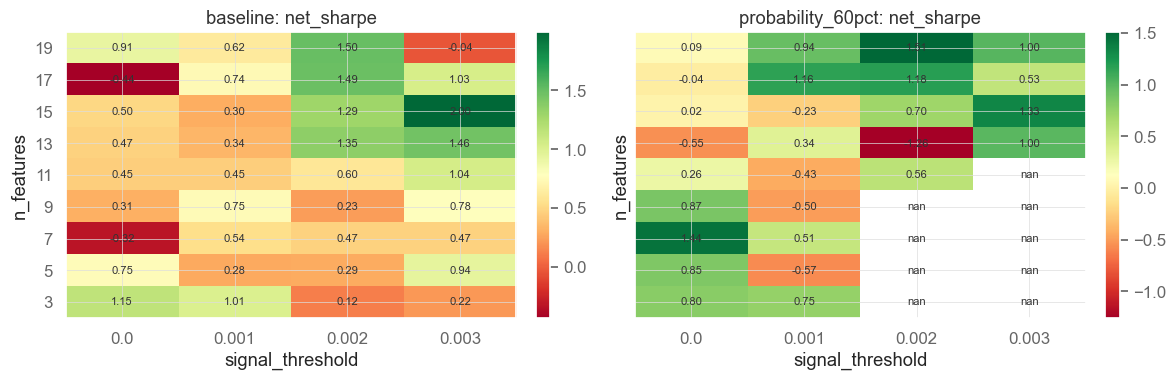

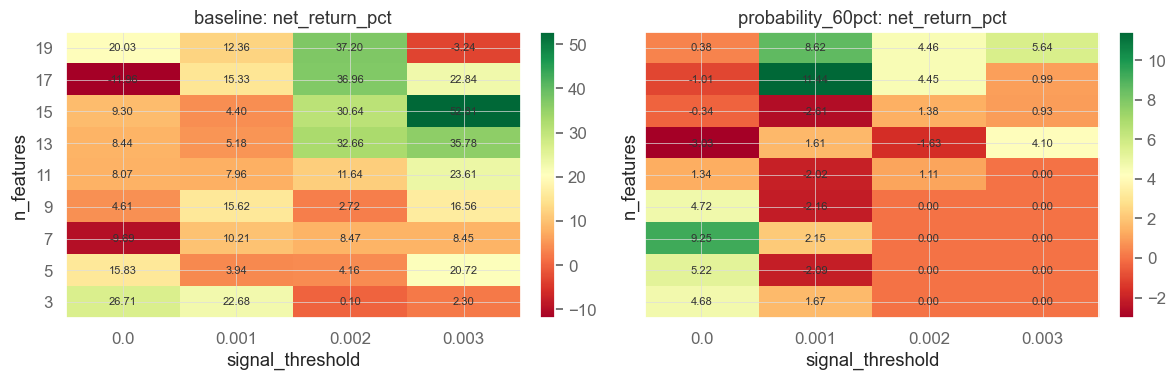

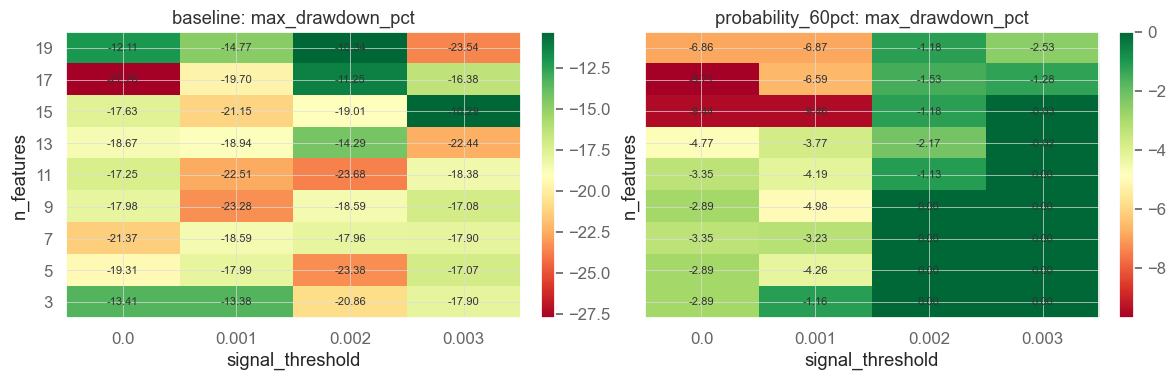

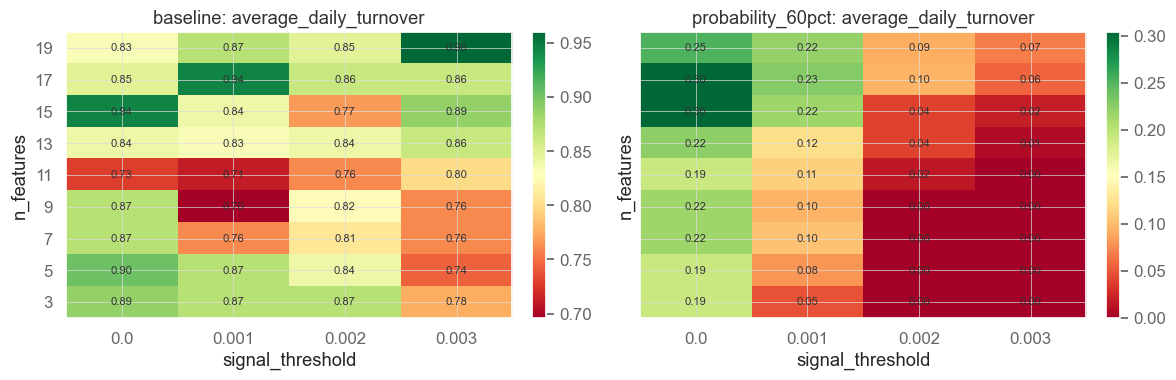

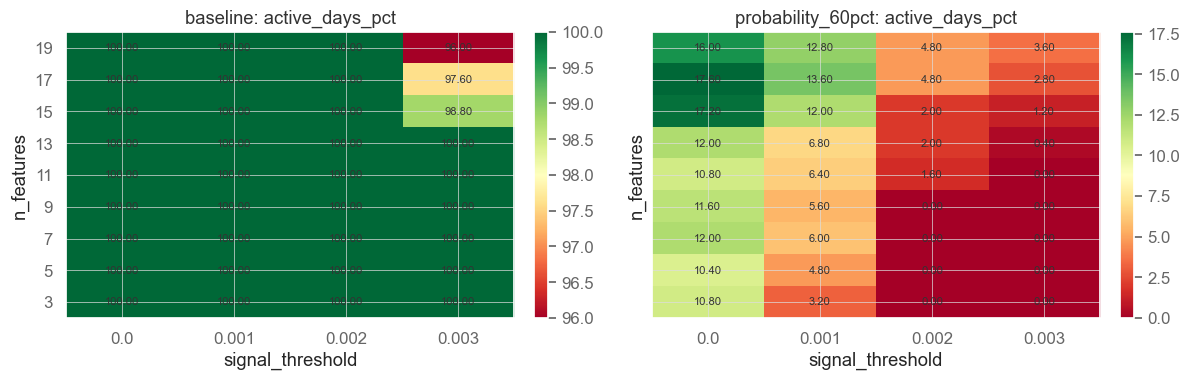

In [8]:
def plot_metric_grid(metric: str):
    fig, axes = plt.subplots(1, len(STRATEGIES), figsize=(6 * len(STRATEGIES), 4), sharey=True)
    if len(STRATEGIES) == 1:
        axes = [axes]

    for ax, strategy_name in zip(axes, STRATEGIES):
        pivot = (
            metrics_df[metrics_df["strategy"] == strategy_name]
            .pivot(index="n_features", columns="signal_threshold", values=metric)
            .sort_index(ascending=False)
        )
        image = ax.imshow(pivot.values, aspect="auto", cmap="RdYlGn")
        ax.set_title(f"{strategy_name}: {metric}")
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels(pivot.columns)
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels(pivot.index)
        ax.set_xlabel("signal_threshold")
        ax.set_ylabel("n_features")
        for row in range(pivot.shape[0]):
            for column in range(pivot.shape[1]):
                ax.text(column, row, f"{pivot.values[row, column]:.2f}", ha="center", va="center", fontsize=8)
        fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()


for metric in ["net_sharpe", "net_return_pct", "max_drawdown_pct", "average_daily_turnover", "active_days_pct"]:
    plot_metric_grid(metric)

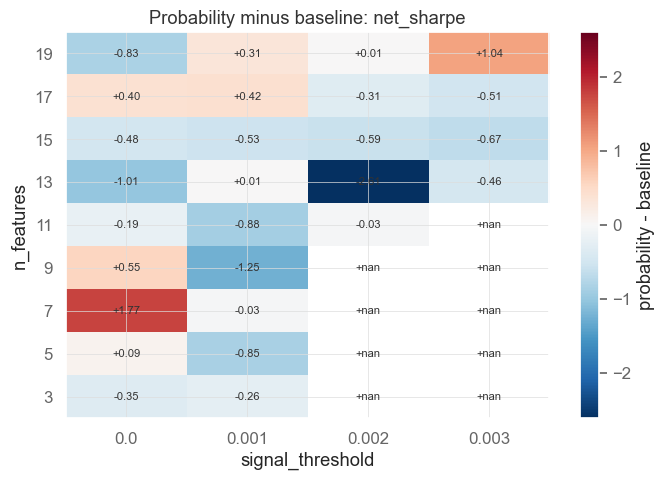

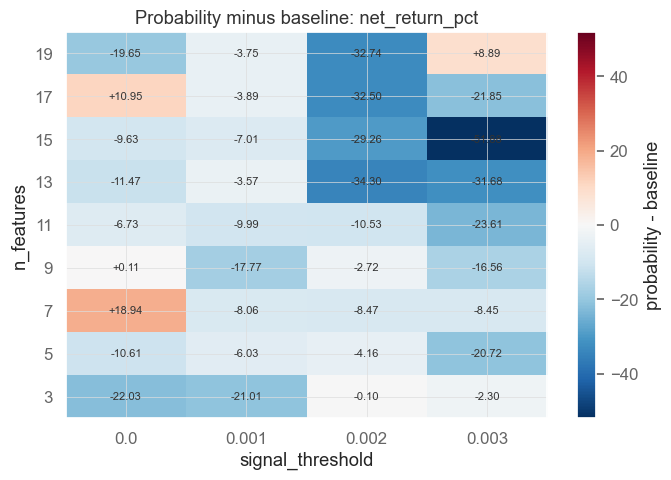

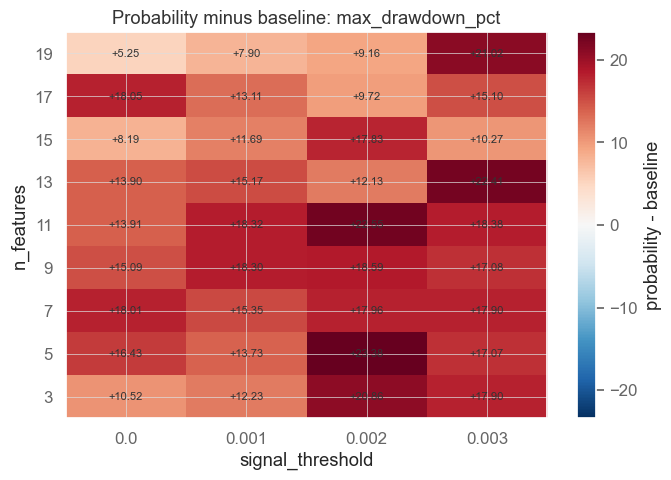

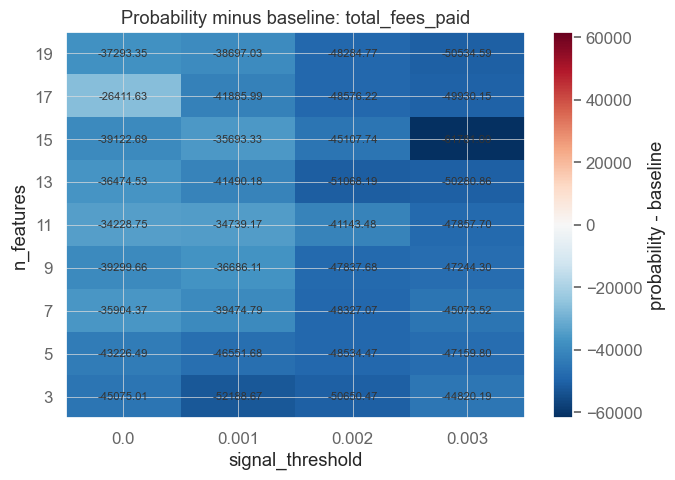

In [9]:
def plot_delta_grid(metric: str):
    pivot = (
        deltas_df[deltas_df["metric"] == metric]
        .pivot(index="n_features", columns="signal_threshold", values="probability_minus_baseline")
        .sort_index(ascending=False)
    )
    bound = np.nanmax(np.abs(pivot.values))
    fig, ax = plt.subplots(figsize=(7, 5))
    image = ax.imshow(pivot.values, aspect="auto", cmap="RdBu_r", vmin=-bound, vmax=bound)
    ax.set_title(f"Probability minus baseline: {metric}")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_xlabel("signal_threshold")
    ax.set_ylabel("n_features")
    for row in range(pivot.shape[0]):
        for column in range(pivot.shape[1]):
            ax.text(column, row, f"{pivot.values[row, column]:+.2f}", ha="center", va="center", fontsize=8)
    fig.colorbar(image, ax=ax, label="probability - baseline")
    plt.tight_layout()
    plt.show()


for metric in ["net_sharpe", "net_return_pct", "max_drawdown_pct", "total_fees_paid"]:
    plot_delta_grid(metric)

## 8. Prediction and Executed-Weight Agreement

The raw predicted class should generally agree because both strategies train the same MLP. Executed weights can differ when the probability strategy rejects predictions at or below 60% confidence.

In [10]:
agreement_records = []

for n_features in N_FEATURES_GRID:
    for signal_threshold in SIGNAL_THRESHOLD_GRID:
        baseline_id = make_run_id(SYMBOL, "baseline", n_features, signal_threshold)
        probability_id = make_run_id(SYMBOL, "probability_60pct", n_features, signal_threshold)
        if baseline_id not in grid_artifacts or probability_id not in grid_artifacts:
            continue

        baseline = grid_artifacts[baseline_id]
        probability = grid_artifacts[probability_id]
        raw = pd.concat(
            [
                baseline["predictions"]["prediction"].rename("baseline"),
                probability["predictions"]["prediction"].rename("probability"),
            ],
            axis=1,
        ).dropna()
        executed = pd.concat(
            [
                baseline["weights"][SYMBOL].rename("baseline"),
                probability["weights"][SYMBOL].rename("probability"),
            ],
            axis=1,
        ).dropna()
        confidence = probability["predictions"]["max_probability"]

        agreement_records.append({
            "n_features": n_features,
            "signal_threshold": signal_threshold,
            "raw_class_agreement_pct": (raw["baseline"] == raw["probability"]).mean() * 100,
            "executed_weight_agreement_pct": (executed["baseline"] == executed["probability"]).mean() * 100,
            "directional_weight_agreement_pct": (np.sign(executed["baseline"]) == np.sign(executed["probability"])).mean() * 100,
            "probability_rejection_pct": (confidence <= PROBABILITY_THRESHOLD).mean() * 100,
            "mean_max_probability": confidence.mean(),
            "median_max_probability": confidence.median(),
        })

agreement_df = pd.DataFrame(agreement_records)
display(agreement_df.round(3))
display(agreement_df.describe().round(3))

,n_features,signal_threshold,raw_class_agreement_pct,executed_weight_agreement_pct,directional_weight_agreement_pct,probability_rejection_pct,mean_max_probability,median_max_probability
0,3,0.000,100.0,10.8,10.8,89.2,0.541,0.530
1,3,0.001,100.0,3.2,3.2,96.8,0.511,0.502
2,3,0.002,100.0,0.0,0.0,100.0,0.481,0.471
3,3,0.003,100.0,0.0,0.0,100.0,0.444,0.441
4,5,0.000,100.0,10.4,10.4,89.6,0.542,0.533
5,5,0.001,100.0,4.8,4.8,95.2,0.513,0.505
6,5,0.002,100.0,0.0,0.0,100.0,0.483,0.477
7,5,0.003,100.0,0.0,0.0,100.0,0.445,0.443
8,7,0.000,100.0,12.0,12.0,88.0,0.541,0.533
9,7,0.001,100.0,6.0,6.0,94.0,0.514,0.505


,n_features,signal_threshold,raw_class_agreement_pct,executed_weight_agreement_pct,directional_weight_agreement_pct,probability_rejection_pct,mean_max_probability,median_max_probability
count,36.000,36.000,36.0,36.000,36.000,36.000,36.000,36.000
mean,11.000,0.002,100.0,6.122,6.122,94.089,0.501,0.491
std,5.237,0.001,0.0,5.617,5.617,5.676,0.037,0.035
min,3.000,0.000,100.0,0.000,0.000,82.400,0.439,0.433
25%,7.000,0.001,100.0,0.300,0.300,89.000,0.477,0.467
50%,11.000,0.002,100.0,5.000,5.000,95.200,0.506,0.495
75%,15.000,0.002,100.0,11.000,11.000,99.700,0.537,0.520
max,19.000,0.003,100.0,17.600,17.600,100.000,0.559,0.546


## 9. Probability Confidence Diagnostics

These plots show how often the 60% cutoff activates and whether higher-confidence grid points correspond to better performance.

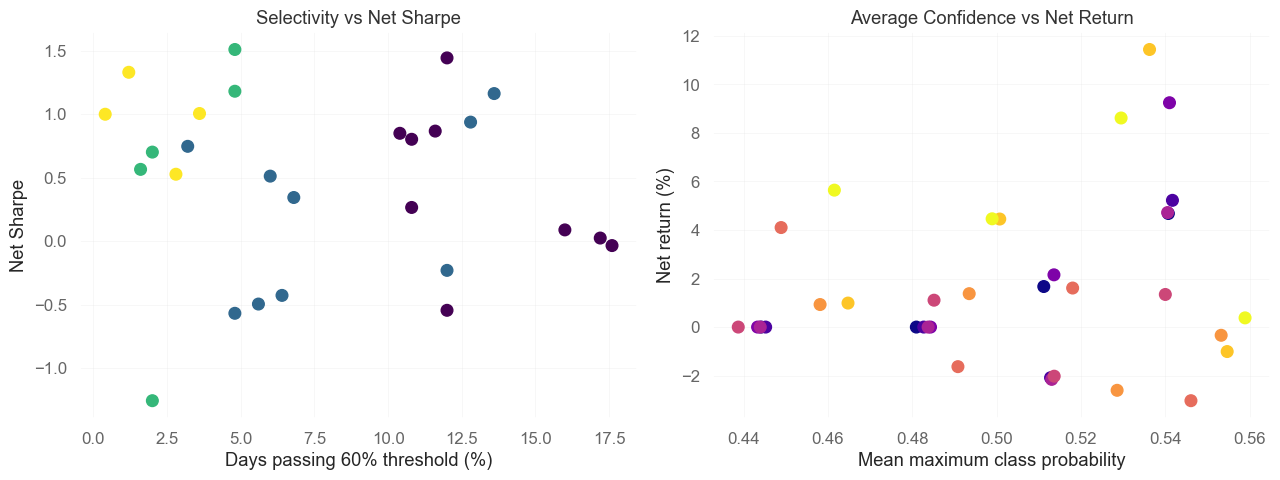

signal_threshold,0.000,0.001,0.002,0.003
n_features,,,,
19,16.0,12.8,4.8,3.6
17,17.6,13.6,4.8,2.8
15,17.2,12.0,2.0,1.2
13,12.0,6.8,2.0,0.4
11,10.8,6.4,1.6,0.0
9,11.6,5.6,0.0,0.0
7,12.0,6.0,0.0,0.0
5,10.4,4.8,0.0,0.0
3,10.8,3.2,0.0,0.0


In [11]:
probability_metrics = metrics_df[metrics_df["strategy"] == "probability_60pct"].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(
    probability_metrics["passes_probability_threshold_pct"],
    probability_metrics["net_sharpe"],
    c=probability_metrics["signal_threshold"],
    cmap="viridis",
    s=70,
)
axes[0].set_xlabel("Days passing 60% threshold (%)")
axes[0].set_ylabel("Net Sharpe")
axes[0].set_title("Selectivity vs Net Sharpe")
axes[0].grid(True, alpha=0.3)

axes[1].scatter(
    probability_metrics["mean_max_probability"],
    probability_metrics["net_return_pct"],
    c=probability_metrics["n_features"],
    cmap="plasma",
    s=70,
)
axes[1].set_xlabel("Mean maximum class probability")
axes[1].set_ylabel("Net return (%)")
axes[1].set_title("Average Confidence vs Net Return")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

confidence_grid = probability_metrics.pivot(
    index="n_features",
    columns="signal_threshold",
    values="passes_probability_threshold_pct",
).sort_index(ascending=False)
display(confidence_grid.round(2))

## 10. Equity Curves for Strategy Winners

This compares the best net-Sharpe run from each strategy with the equal-weight benchmark used by the vector backtester.

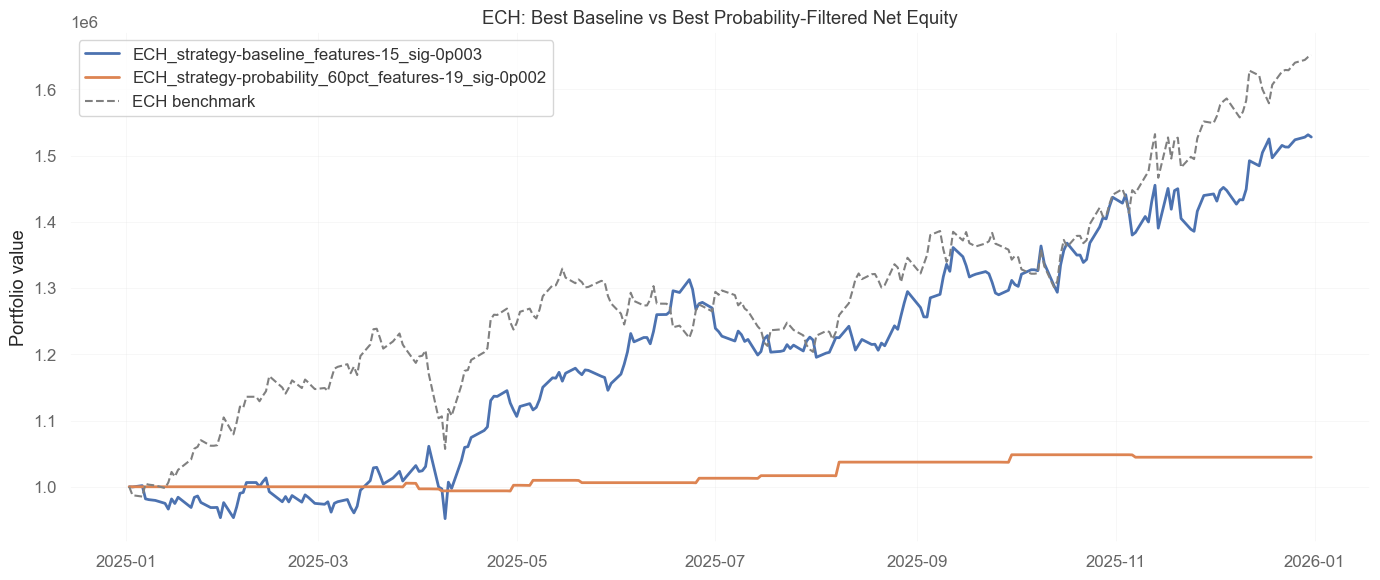

In [12]:
fig, ax = plt.subplots(figsize=(14, 6))

for _, row in best_by_strategy.iterrows():
    run_id = row["run_id"]
    stats = grid_artifacts[run_id]["stats"]
    ax.plot(stats.index, stats["net_equity"], label=run_id, linewidth=2)

benchmark_stats = grid_artifacts[best_by_strategy.iloc[0]["run_id"]]["stats"]
ax.plot(
    benchmark_stats.index,
    INITIAL_CAPITAL * benchmark_stats["cum_benchmark"],
    color="gray",
    linestyle="--",
    label=f"{SYMBOL} benchmark",
)

ax.set_title(f"{SYMBOL}: Best Baseline vs Best Probability-Filtered Net Equity")
ax.set_ylabel("Portfolio value")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Interpretation Checklist

After the grid completes, compare:

- Net Sharpe and net return, not only gross return.
- Matched-grid deltas rather than only each strategy's single best case.
- Max drawdown, turnover, fees, exposure, and percentage of active days.
- Whether improvements persist across neighboring `n_features` and `signal_threshold` values.
- Raw prediction agreement versus executed-weight agreement.
- How often the probability strategy rejects predictions and whether that selectivity improves risk-adjusted performance.
- Whether the best result is robust enough to justify testing other probability thresholds in a separate experiment.